|<img style="float:left;" src="images/usherb_transp.gif"> |Pierre Proulx, ing, professeur|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|


### Section18.7, Difffusion et réaction dans un catalyseur poreux sphérique

#### Même notebook que précédemment mais en utilisant le module de Thiele comme variable de tracage, plus clair.

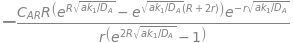

In [1]:
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline
# Paramètres, variables et fonctions
r,delta_r,R,k_1,a,D_A,C_AR=sp.symbols('r,delta_r,R,k_1,a,D_A,C_AR')                                                            
N_A=sp.Function('N_A')
C_A=sp.Function('C_A')(r)   
f=sp.Function('f')(r)
eq=sp.Eq(sp.diff(N_A(r)*r**2,r)+k_1*a*C_A*r**2,0)
eq=eq.subs(N_A(r),-D_A*sp.diff(C_A))
### suggestion de transformation faite dans Bird pour solutionner
eqt=sp.Eq(f.diff(r,r)-k_1*a/D_A*f,0)
t=sp.dsolve(eqt)
C=sp.symbols('C')   # C est défini comme C_A/C_AR ici
C=(t.rhs/r).simplify()
display(C)                    # cette expression est équivalente à 18-7.8
cl1=r**2*sp.diff(C,r)   
cl1=sp.cancel(cl1) #pour faire effectuer les multiplications et divisions de r et r2
cl1=cl1.subs(r,0)
cl2=sp.Eq(C.subs(r,R)-C_AR,0)    # à la surface, C_A = C_AR
cl2=cl2.lhs
constantes=sp.solve([cl1,cl2],sp.symbols('C1 C2'))
C_A=C.subs(constantes)
display(sp.simplify(C_A))

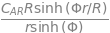

In [2]:
Thiele=sp.symbols('Phi')
C_A1=C_AR*R/r*sp.sinh(Thiele*r/R)/sp.sinh(Thiele)
display(C_A1)

In [3]:
#
# Tracer le profil pour différentes valeurs de la constante de réaction
#
dico={'C_AR':1,'R':0.01}
import matplotlib.pyplot as plt
from ipywidgets import *
plt.rcParams['figure.figsize']=8,4
C_A1=C_A1.subs(dico)
def f(Th):
    C=C_A1.subs(Thiele,Th).evalf()
    # petite détail qui m'a fait perdre un peu de temps, la solution est indéterminée en r=0, donc j'utilise 1e-20 comme limite
    p = sp.plot(C,(r,1e-20,R.subs(dico)),
                legend=True, title='Concentration radiale en fonction de Thiele',
                xlabel='r',ylabel='C_a',ylim=[0,1],show=False) 
    p[0].line_color = 'blue'
    p[0].label='Thiele='+str(Th)
    p.show()
g=interactive(f,Th=(0.1,10,0.1))
display(g)

interactive(children=(FloatSlider(value=5.0, description='Th', max=10.0, min=0.1), Output()), _dom_classes=('w…